In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
bitacora = pd.read_csv("Analisis GAC Full7agosto 2026(Bitacora de Piso).csv")

bitacora.head()

,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,...,NaN,NaN,NaN,NaN,NaN,NaN,Items,Items,items,items
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,Aurelio,Activo,Aprobada,Lead Interes Medio
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pedro,Cerrado,Condicionada,Lead InteresBajo


In [3]:
print("Dimensiones:", bitacora.shape)
print(bitacora.columns)

Dimensiones: (234, 30)
Index(['Fecha', 'Nombre Cliente ', 'Telefono ', 'Asesor ', 'Esatus Lead',
       'PDM', 'SDC', 'Estatus de SDC ', 'Venta', 'Temperatura ',
       'Inter Gerente', '¿Por que no hubo prueba de manejo?',
       '¿Por que no hubo Solicitud de credito?',
       '¿Por que no hubo intervencion del Gerente?',
       '¿Por que no hubo proceso wow?',
       '¿Por que no se ha formalizado la compra?',
       '5 porques clientes de piso ', 'Comentarios', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29'],
      dtype='str')


In [4]:
bitacora.isnull().sum()

Fecha                                          36
Nombre Cliente                                 37
Telefono                                      234
Asesor                                         38
Esatus Lead                                    37
PDM                                             0
SDC                                            18
Estatus de SDC                                232
Venta                                          18
Temperatura                                   224
Inter Gerente                                  18
¿Por que no hubo prueba de manejo?            218
¿Por que no hubo Solicitud de credito?        220
¿Por que no hubo intervencion del Gerente?    223
¿Por que no hubo proceso wow?                 222
¿Por que no se ha formalizado la compra?      223
5 porques clientes de piso                    226
Comentarios                                   212
Unnamed: 18                                   234
Unnamed: 19                                   234


In [5]:
bitacora.columns = bitacora.columns.str.strip()

In [6]:
bitacora_limpia = bitacora.copy()

In [7]:
bitacora_limpia = bitacora_limpia.iloc[:209].copy()

In [8]:
#Columnas a eliminar
columnas_eliminar = [
    "Telefono",
    "Temperatura",
    "Estatus de SDC"
]

# Agregar todas las columnas que empiecen con "Unnamed"
columnas_eliminar += [
    col for col in bitacora_limpia.columns 
    if col.startswith("Unnamed")
]

# Eliminar columnas solo de la copia
bitacora_limpia = bitacora_limpia.drop(columns=columnas_eliminar)

In [9]:
print("Copia limpia:", bitacora_limpia.shape)

Copia limpia: (209, 15)


In [10]:
# Eliminar las filas de Excel 57 a 67
bitacora_limpia = bitacora_limpia.drop(index=range(55, 66))

In [11]:
print(bitacora_limpia.shape)
bitacora_limpia.iloc[50:60]

(198, 15)


,Fecha,Nombre Cliente,Asesor,Esatus Lead,PDM,SDC,Venta,Inter Gerente,¿Por que no hubo prueba de manejo?,¿Por que no hubo Solicitud de credito?,¿Por que no hubo intervencion del Gerente?,¿Por que no hubo proceso wow?,¿Por que no se ha formalizado la compra?,5 porques clientes de piso,Comentarios
50,05/06/2025,Rocío,Victor,Activo,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,contesto y colgo
51,05/06/2025,Jesus Olvera Sanchez,Pedro,Activo,True,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,No entra llamada
52,05/06/2025,Francisco Valencia,Pedro,Activo,False,False,False,True,No habia unidad para PDM,NaN,NaN,NaN,NaN,NaN,Buena atencion
53,05/06/2025,Juan Gomez,Victor,Activo,True,False,False,True,NaN,No quiere tramitar se inclina por TIguan,NaN,NaN,Se inclina por Tiguan,NaN,Buena atencion
54,05/06/2025,Faviola Villar,Victor,Activo,False,False,False,False,NaN,NaN,NaN,NaN,Por motivos de inversion no pretende compra,NaN,Buena Atencion por el momento no pretende hac...
66,05/08/2025,Hanny Trejo,Victor,Activo,True,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,No entra llamada
67,05/09/2025,Manuel Domínguez Ramírez,Aurelio,Activo,True,False,True,True,El cliente no desea hacer prueba de manejo,Es compra de contado,"Sí hubo intervención con el gerente de ventas,...",El mismo día recorrio todas las agencias y lo...,Ya se formalizo la compra y entrego la camioneta.,NaN,Buena atencion compro GS4
68,05/09/2025,Gerardo Cabañas,Mauricio,Cerrado,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,No contesta
69,05/10/2025,Jose Juan Florentino González,Mauricio,Activo,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,No contesta
70,05/10/2025,Angel Aguilar,Pedro,Activo,False,False,False,False,"Falta de tiempo, no venia con su pareja",NaN,NaN,NaN,NaN,NaN,Buena atencion esta viendo opciones


In [12]:
print("Número de filas:", bitacora_limpia.shape[0])
bitacora_limpia.tail()

Número de filas: 198


,Fecha,Nombre Cliente,Asesor,Esatus Lead,PDM,SDC,Venta,Inter Gerente,¿Por que no hubo prueba de manejo?,¿Por que no hubo Solicitud de credito?,¿Por que no hubo intervencion del Gerente?,¿Por que no hubo proceso wow?,¿Por que no se ha formalizado la compra?,5 porques clientes de piso,Comentarios
204,07/09/2025,David Moran,Aurelio Torres,Activo,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205,07/10/2025,Medeo Martínez Ferro,Pedro González,Activo,True,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
206,07/10/2025,Luis Ballesteros,Miguel Ramírez,Activo,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207,07/10/2025,Movex,Aurelio Torres,Venta,False,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208,08/01/2025,NaN,NaN,NaN,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
bitacora_limpia.columns.tolist()

['Fecha',
 'Nombre Cliente',
 'Asesor',
 'Esatus Lead',
 'PDM',
 'SDC',
 'Venta',
 'Inter Gerente',
 '¿Por que no hubo prueba de manejo?',
 '¿Por que no hubo Solicitud de credito?',
 '¿Por que no hubo intervencion del Gerente?',
 '¿Por que no hubo proceso wow?',
 '¿Por que no se ha formalizado la compra?',
 '5 porques clientes de piso',
 'Comentarios']

In [14]:
variable1 = "¿Por que no hubo prueba de manejo?"

datos1 = bitacora_limpia[variable1].dropna()

In [15]:
def categorizar_pdm(respuesta):

    respuesta = str(respuesta).lower()

    if "si hubo" in respuesta or "sí hubo" in respuesta or "realizo prueba" in respuesta or "realizó prueba" in respuesta:
        return "Sí hubo prueba"

    elif "falta de tiempo" in respuesta or "tiempo" in respuesta:
        return "Falta de tiempo"

    elif "no habia unidad" in respuesta or "no había unidad" in respuesta:
        return "No había unidad"

    elif "no desea" in respuesta or "no quiso" in respuesta:
        return "Cliente no quiso"

    elif "sabado" in respuesta or "sábado" in respuesta or "piensa acudir" in respuesta or "prefiere que ella la maneje" in respuesta:
        return "Pendiente / otro día"

    else:
        return "Otro motivo"

In [16]:
# Categorizar únicamente los datos que sí tienen respuesta
motivo_pdm = datos1.apply(categorizar_pdm)

In [17]:
tabla_pdm = motivo_pdm.value_counts().reset_index()

tabla_pdm.columns = ["Categoría", "Frecuencia"]

tabla_pdm["Porcentaje"] = (
    tabla_pdm["Frecuencia"] / tabla_pdm["Frecuencia"].sum()
) * 100

tabla_pdm

,Categoría,Frecuencia,Porcentaje
0,Sí hubo prueba,5,31.25
1,Pendiente / otro día,3,18.75
2,Otro motivo,3,18.75
3,Cliente no quiso,2,12.50
4,Falta de tiempo,2,12.50
5,No había unidad,1,6.25


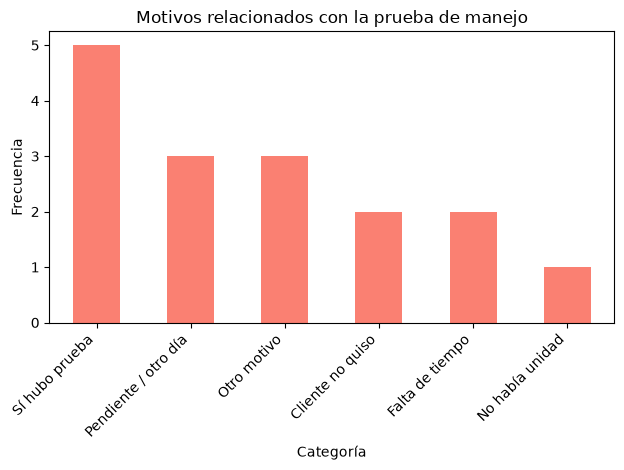

In [100]:
motivo_pdm.value_counts().plot(kind="bar", color="salmon")

plt.title("Motivos relacionados con la prueba de manejo")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
variable2 = "¿Por que no hubo Solicitud de credito?"

datos2 = bitacora_limpia[variable2].dropna()

In [20]:
def categorizar_sdc(respuesta):

    respuesta = str(respuesta).lower()

    if (
        "si hubo" in respuesta
        or "sí hubo" in respuesta
        or "ingresa sdc" in respuesta
        or "se hizo solicitud" in respuesta
    ):
        return "Sí hubo SDC"

    elif "contado" in respuesta:
        return "Compra de contado"

    elif (
        "no quiere tramitar" in respuesta
        or "no desea tramitar" in respuesta
        or "no quiere credito" in respuesta
        or "no quiere crédito" in respuesta
    ):
        return "No quiere tramitar"

    elif (
        "despues" in respuesta
        or "después" in respuesta
        or "pendiente" in respuesta
        or "esperar" in respuesta
        or "considerando" in respuesta
    ):
        return "Pendiente / decisión posterior"

    elif (
        "capacidad" in respuesta
        or "perfil" in respuesta
        or "financiera" in respuesta
    ):
        return "Problemas de capacidad o perfil"

    else:
        return "Otro motivo"

In [21]:
motivo_sdc = datos2.apply(categorizar_sdc)

In [22]:
tabla_sdc = motivo_sdc.value_counts().reset_index()

tabla_sdc.columns = ["Categoría", "Frecuencia"]

tabla_sdc["Porcentaje"] = (
    tabla_sdc["Frecuencia"] / tabla_sdc["Frecuencia"].sum()
) * 100

tabla_sdc

,Categoría,Frecuencia,Porcentaje
0,Compra de contado,4,28.571429
1,Pendiente / decisión posterior,3,21.428571
2,Otro motivo,2,14.285714
3,Sí hubo SDC,2,14.285714
4,Problemas de capacidad o perfil,2,14.285714
5,No quiere tramitar,1,7.142857


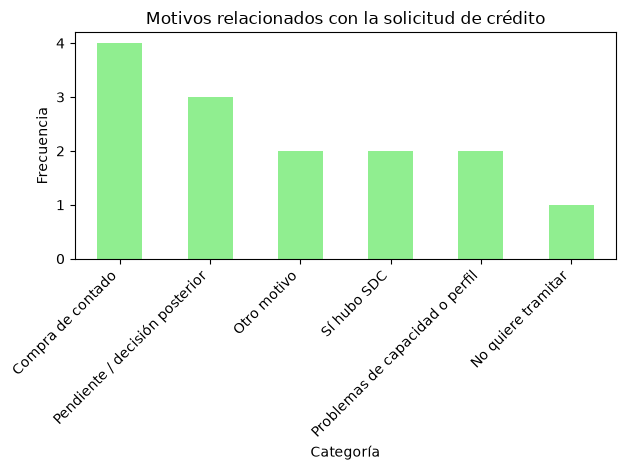

In [101]:
motivo_sdc.value_counts().plot(kind="bar", color="lightgreen")

plt.title("Motivos relacionados con la solicitud de crédito")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [24]:
variable3 = "¿Por que no hubo intervencion del Gerente?"

datos3 = bitacora_limpia[variable3].dropna()

In [25]:
def categorizar_gerente(respuesta):

    respuesta = str(respuesta).lower()

    if (
        "si hubo" in respuesta
        or "sí hubo" in respuesta
        or "yo atendí" in respuesta
        or "yo atendi" in respuesta
        or "intervino" in respuesta
    ):
        return "Sí hubo intervención"

    elif (
        "llamada" in respuesta
        or "seguimiento" in respuesta
        or "posterior" in respuesta
    ):
        return "Seguimiento posterior"

    elif (
        "vacaciones" in respuesta
        or "descanso" in respuesta
        or "no estaba" in respuesta
        or "no se encontraba" in respuesta
    ):
        return "Gerente no disponible"

    else:
        return "Otro motivo"

In [26]:
motivo_gerente = datos3.apply(categorizar_gerente)

In [27]:
tabla_gerente = motivo_gerente.value_counts().reset_index()

tabla_gerente.columns = ["Categoría", "Frecuencia"]

tabla_gerente["Porcentaje"] = (
    tabla_gerente["Frecuencia"] / tabla_gerente["Frecuencia"].sum()
) * 100

tabla_gerente

,Categoría,Frecuencia,Porcentaje
0,Sí hubo intervención,9,81.818182
1,Seguimiento posterior,2,18.181818


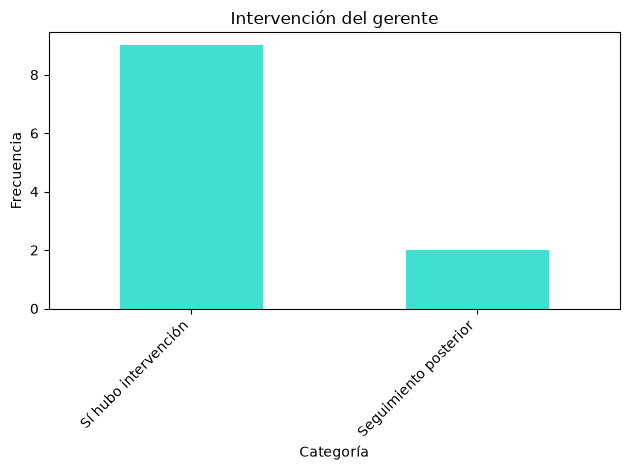

In [165]:
motivo_gerente.value_counts().plot(kind="bar", color="turquoise")

plt.title("Intervención del gerente")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [29]:
Leads = pd.read_csv("Analisis GAC Full7agosto 2026(Leads Reales).csv", header=2)
Leads.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN,NaN


In [30]:
header=2

In [31]:
valores_nulos_Leads = Leads.isnull().sum()
valores_nulos_Leads

Año                     41
Mes                     11
Total                   13
Ilocalizable            12
No Contesta             13
D. Incorrectos          13
Duplicados              11
Efectivos               14
Abiertos                12
Ventas                  14
Conversion              10
Efectividad de Leads    14
Unnamed: 12             42
Unnamed: 13             44
dtype: int64

In [32]:
# Rellenar únicamente las filas correspondientes a A4:A32
Leads.loc[0:28, "Año"] = Leads.loc[0:28, "Año"].ffill()
Leads.loc[0:28, ["Año", "Mes"]]

,Año,Mes
0,2024.0,Enero
1,2024.0,Febrero
2,2024.0,Marzo
3,2024.0,Abril
4,2024.0,Mayo
5,2024.0,Junio
6,2024.0,Julio
7,2024.0,Agosto
8,2024.0,Septiembre
9,2024.0,Octubre


In [33]:
valores_nulos_Leads = Leads.isnull().sum()
valores_nulos_Leads

Año                     15
Mes                     11
Total                   13
Ilocalizable            12
No Contesta             13
D. Incorrectos          13
Duplicados              11
Efectivos               14
Abiertos                12
Ventas                  14
Conversion              10
Efectividad de Leads    14
Unnamed: 12             42
Unnamed: 13             44
dtype: int64

In [34]:
# Crear copia de la base original
leads_limpia = Leads.copy()

In [168]:
# Convertir Duplicados a numérica
leads_limpia["Duplicados"] = (
    leads_limpia["Duplicados"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

leads_limpia["Duplicados"] = pd.to_numeric(
    leads_limpia["Duplicados"],
    errors="coerce"
)

# Quitar NaN únicamente de Duplicados
datos_duplicados = leads_limpia["Duplicados"].dropna()

print("Datos usados:", len(datos_duplicados))
print("NaN restantes:", datos_duplicados.isna().sum())

Datos usados: 29
NaN restantes: 0


In [169]:
# Número de datos
n_duplicados = len(datos_duplicados)

# Máximo y mínimo
Max_duplicados = datos_duplicados.max()
Min_duplicados = datos_duplicados.min()

# Rango
R_duplicados = Max_duplicados - Min_duplicados

# Número de intervalos según Sturges
ni_duplicados = 1 + 3.32 * np.log10(n_duplicados)

# Ancho del intervalo
i_duplicados = R_duplicados / ni_duplicados

print("n:", n_duplicados)
print("Mínimo:", Min_duplicados)
print("Máximo:", Max_duplicados)
print("Rango:", R_duplicados)
print("Intervalos según Sturges:", ni_duplicados)
print("Ancho del intervalo:", i_duplicados)

n: 29
Mínimo: 0.0
Máximo: 136.0
Rango: 136.0
Intervalos según Sturges: 5.855161353024534
Ancho del intervalo: 23.22737014407776


In [171]:
ni_duplicados_redondeado = round(ni_duplicados)

ni_duplicados_redondeado

6

In [172]:
intervalos_duplicados = np.linspace(
    Min_duplicados,
    Max_duplicados,
    ni_duplicados_redondeado + 1
)

intervalos_duplicados

array([  0.        ,  22.66666667,  45.33333333,  68.        ,
        90.66666667, 113.33333333, 136.        ])

In [173]:
niveles_duplicados = [
    "Muy bajo",
    "Bajo",
    "Medio-bajo",
    "Medio",
    "Medio-alto",
    "Alto",
    "Muy alto"
]

categorias_duplicados = []

for x in range(ni_duplicados_redondeado):

    etiqueta = (
        f"{niveles_duplicados[x]} "
        f"({intervalos_duplicados[x]:.0f} - "
        f"{intervalos_duplicados[x+1]:.0f})"
    )

    categorias_duplicados.append(etiqueta)

categorias_duplicados

['Muy bajo (0 - 23)',
 'Bajo (23 - 45)',
 'Medio-bajo (45 - 68)',
 'Medio (68 - 91)',
 'Medio-alto (91 - 113)',
 'Alto (113 - 136)']

In [174]:
duplicados_categorizado = pd.cut(
    x=datos_duplicados,
    bins=intervalos_duplicados,
    labels=categorias_duplicados,
    include_lowest=True
)

duplicados_categorizado

1         Muy bajo (0 - 23)
2         Muy bajo (0 - 23)
3         Muy bajo (0 - 23)
4         Muy bajo (0 - 23)
5         Muy bajo (0 - 23)
6         Muy bajo (0 - 23)
7         Muy bajo (0 - 23)
8            Bajo (23 - 45)
9         Muy bajo (0 - 23)
10        Muy bajo (0 - 23)
11     Medio-bajo (45 - 68)
12         Alto (113 - 136)
13           Bajo (23 - 45)
14     Medio-bajo (45 - 68)
15          Medio (68 - 91)
16        Muy bajo (0 - 23)
17     Medio-bajo (45 - 68)
18    Medio-alto (91 - 113)
19     Medio-bajo (45 - 68)
20        Muy bajo (0 - 23)
21        Muy bajo (0 - 23)
22     Medio-bajo (45 - 68)
23           Bajo (23 - 45)
24     Medio-bajo (45 - 68)
25           Bajo (23 - 45)
26           Bajo (23 - 45)
27           Bajo (23 - 45)
28        Muy bajo (0 - 23)
31           Bajo (23 - 45)
Name: Duplicados, dtype: category
Categories (6, str): ['Muy bajo (0 - 23)' < 'Bajo (23 - 45)' < 'Medio-bajo (45 - 68)' < 'Medio (68 - 91)' < 'Medio-alto (91 - 113)' < 'Alto (113 - 136)']

In [175]:
Tabla_freq_duplicados = (
    duplicados_categorizado
    .value_counts()
    .reset_index()
)

Tabla_freq_duplicados.columns = [
    "Duplicados",
    "count"
]

Tabla_freq_duplicados

,Duplicados,count
0,Muy bajo (0 - 23),13
1,Bajo (23 - 45),7
2,Medio-bajo (45 - 68),6
3,Medio (68 - 91),1
4,Medio-alto (91 - 113),1
5,Alto (113 - 136),1


In [176]:
Filtro_duplicados = Tabla_freq_duplicados[
    Tabla_freq_duplicados["count"] > 0
]

Filtro_duplicados

,Duplicados,count
0,Muy bajo (0 - 23),13
1,Bajo (23 - 45),7
2,Medio-bajo (45 - 68),6
3,Medio (68 - 91),1
4,Medio-alto (91 - 113),1
5,Alto (113 - 136),1


In [179]:
Filtro_index_duplicados = (
    Filtro_duplicados
    .set_index("Duplicados")
)

In [180]:
Filtro_index_duplicados = (
    Filtro_index_duplicados
    .reindex(categorias_duplicados)
    .dropna()
)

Filtro_index_duplicados

,count
Duplicados,
Muy bajo (0 - 23),13
Bajo (23 - 45),7
Medio-bajo (45 - 68),6
Medio (68 - 91),1
Medio-alto (91 - 113),1
Alto (113 - 136),1


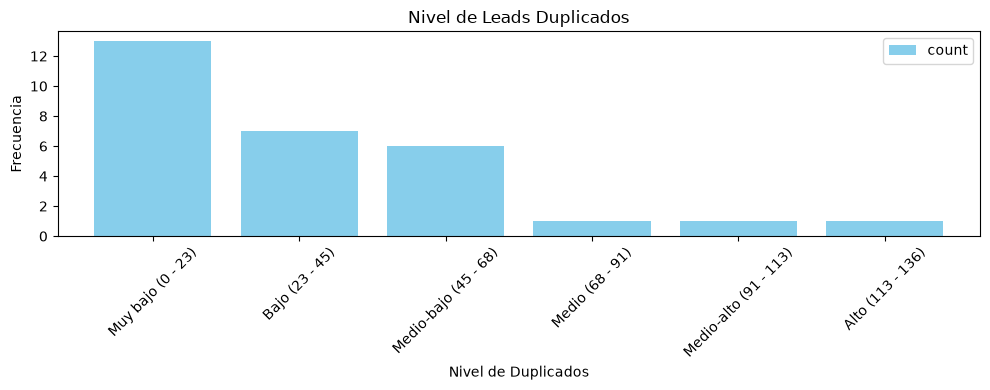

In [181]:
Filtro_index_duplicados.plot(
    kind="bar",
    width=0.8,
    figsize=(10,4),
    color="skyblue",
    rot=45
)

plt.title("Nivel de Leads Duplicados")
plt.xlabel("Nivel de Duplicados")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [51]:
leads_limpia["Efectivos"] = (
    leads_limpia["Efectivos"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

leads_limpia["Efectivos"] = pd.to_numeric(
    leads_limpia["Efectivos"],
    errors="coerce"
)

In [52]:
datos_efectivos = leads_limpia["Efectivos"].dropna()

In [53]:
# Calculamos el número total de datos "n"
n_efectivos = len(datos_efectivos)

n_efectivos

29

In [54]:
# Obtenemos límite superior e inferior
Max_efectivos = datos_efectivos.max()
Min_efectivos = datos_efectivos.min()

Limites_efectivos = [Min_efectivos, Max_efectivos]

Limites_efectivos

[np.float64(128.0), np.float64(1040.0)]

In [55]:
# Calculamos el rango R
R_efectivos = Max_efectivos - Min_efectivos

R_efectivos

np.float64(912.0)

In [56]:
# Calculamos el número de intervalos de clase
ni_efectivos = 1 + 3.32 * np.log10(n_efectivos)

ni_efectivos

np.float64(5.855161353024534)

In [57]:
# Calculamos el ancho del intervalo
i_efectivos = R_efectivos / ni_efectivos

i_efectivos

np.float64(155.7600115544038)

In [58]:
ni_efectivos_redondeado = round(ni_efectivos)

ni_efectivos_redondeado

6

In [59]:
intervalos_efectivos = np.linspace(
    Min_efectivos,
    Max_efectivos,
    ni_efectivos_redondeado + 1
)

intervalos_efectivos

array([ 128.,  280.,  432.,  584.,  736.,  888., 1040.])

In [112]:
niveles_efectivos = [
    "Muy bajo",
    "Bajo",
    "Medio-bajo",
    "Medio",
    "Medio-alto",
    "Alto"
]

categorias_efectivos = []

for x in range(ni_efectivos_redondeado):

    etiqueta = (
        f"{niveles_efectivos[x]} "
        f"({intervalos_efectivos[x]:.0f} - "
        f"{intervalos_efectivos[x+1]:.0f})"
    )

    categorias_efectivos.append(etiqueta)

categorias_efectivos

['Muy bajo (128 - 280)',
 'Bajo (280 - 432)',
 'Medio-bajo (432 - 584)',
 'Medio (584 - 736)',
 'Medio-alto (736 - 888)',
 'Alto (888 - 1040)']

In [113]:
efectivos_categorizado = pd.cut(
    x=datos_efectivos,
    bins=intervalos_efectivos,
    labels=categorias_efectivos,
    include_lowest=True
)

efectivos_categorizado

1           Bajo (280 - 432)
2       Muy bajo (128 - 280)
3           Bajo (280 - 432)
4       Muy bajo (128 - 280)
5          Medio (584 - 736)
6     Medio-bajo (432 - 584)
7     Medio-bajo (432 - 584)
8     Medio-bajo (432 - 584)
9     Medio-alto (736 - 888)
10         Alto (888 - 1040)
11         Alto (888 - 1040)
12         Medio (584 - 736)
13    Medio-bajo (432 - 584)
14         Medio (584 - 736)
15    Medio-alto (736 - 888)
16    Medio-bajo (432 - 584)
17         Medio (584 - 736)
18         Alto (888 - 1040)
19         Medio (584 - 736)
20         Medio (584 - 736)
21         Medio (584 - 736)
22    Medio-alto (736 - 888)
23         Medio (584 - 736)
24         Medio (584 - 736)
25         Medio (584 - 736)
26         Alto (888 - 1040)
27         Medio (584 - 736)
28         Medio (584 - 736)
31         Medio (584 - 736)
Name: Efectivos, dtype: category
Categories (6, str): ['Muy bajo (128 - 280)' < 'Bajo (280 - 432)' < 'Medio-bajo (432 - 584)' < 'Medio (584 - 736)' < 'Medio-al

In [114]:
# Análisis univariado
Tabla_freq_efectivos = efectivos_categorizado.value_counts().reset_index()

Tabla_freq_efectivos

,Efectivos,count
0,Medio (584 - 736),13
1,Medio-bajo (432 - 584),5
2,Alto (888 - 1040),4
3,Medio-alto (736 - 888),3
4,Muy bajo (128 - 280),2
5,Bajo (280 - 432),2


In [115]:
Tabla_freq_efectivos.columns = ["Efectivos", "count"]

Tabla_freq_efectivos

,Efectivos,count
0,Medio (584 - 736),13
1,Medio-bajo (432 - 584),5
2,Alto (888 - 1040),4
3,Medio-alto (736 - 888),3
4,Muy bajo (128 - 280),2
5,Bajo (280 - 432),2


In [116]:
Filtro_efectivos = Tabla_freq_efectivos[
    Tabla_freq_efectivos["count"] > 0
]

Filtro_efectivos

,Efectivos,count
0,Medio (584 - 736),13
1,Medio-bajo (432 - 584),5
2,Alto (888 - 1040),4
3,Medio-alto (736 - 888),3
4,Muy bajo (128 - 280),2
5,Bajo (280 - 432),2


In [117]:
Filtro_index_efectivos = Filtro_efectivos.set_index("Efectivos")

Filtro_index_efectivos

,count
Efectivos,
Medio (584 - 736),13
Medio-bajo (432 - 584),5
Alto (888 - 1040),4
Medio-alto (736 - 888),3
Muy bajo (128 - 280),2
Bajo (280 - 432),2


In [119]:
orden_efectivos = categorias_efectivos

Filtro_index_efectivos = (
    Filtro_index_efectivos
    .reindex(orden_efectivos)
    .dropna()
)

Filtro_index_efectivos

,count
Efectivos,
Muy bajo (128 - 280),2
Bajo (280 - 432),2
Medio-bajo (432 - 584),5
Medio (584 - 736),13
Medio-alto (736 - 888),3
Alto (888 - 1040),4


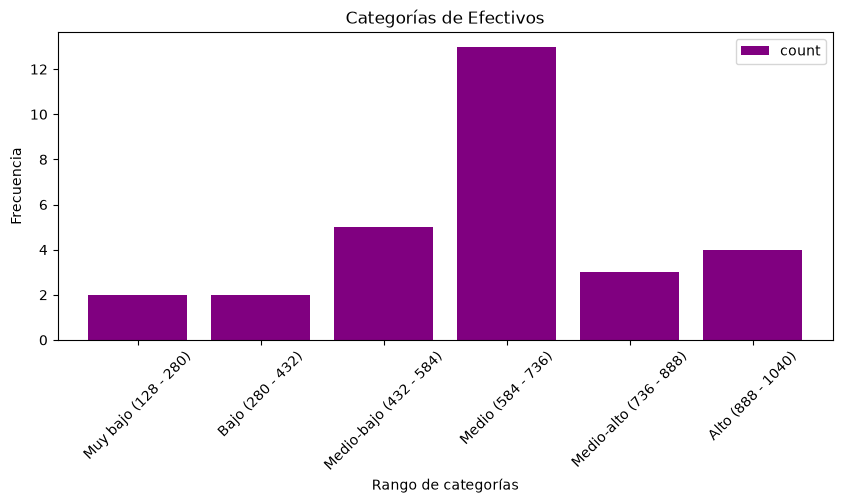

In [120]:
Filtro_index_efectivos.plot(
    kind="bar",
    width=0.8,
    figsize=(10,4),
    color="purple",
    rot=45
)

plt.title("Categorías de Efectivos")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")

plt.show()

In [67]:
# Convertimos la variable Ventas a numérica
leads_limpia["Ventas"] = (
    leads_limpia["Ventas"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

leads_limpia["Ventas"] = pd.to_numeric(
    leads_limpia["Ventas"],
    errors="coerce"
)

# Quitamos los valores nulos solo de Ventas
datos_ventas = leads_limpia["Ventas"].dropna()

In [68]:
# Número total de datos
n_ventas = len(datos_ventas)

n_ventas

29

In [69]:
# Límite superior e inferior
Max_ventas = datos_ventas.max()
Min_ventas = datos_ventas.min()

Limites_ventas = [Min_ventas, Max_ventas]

Limites_ventas

[np.float64(6.0), np.float64(41.0)]

In [70]:
# Calculamos el rango
R_ventas = Max_ventas - Min_ventas

R_ventas

np.float64(35.0)

In [71]:
# Número de intervalos de clase
ni_ventas = 1 + 3.32 * np.log10(n_ventas)

ni_ventas

np.float64(5.855161353024534)

In [72]:
# Ancho del intervalo
i_ventas = R_ventas / ni_ventas

i_ventas

np.float64(5.977632022372953)

In [73]:
ni_ventas_redondeado = round(ni_ventas)

ni_ventas_redondeado

6

In [74]:
intervalos_ventas = np.linspace(
    Min_ventas,
    Max_ventas,
    ni_ventas_redondeado + 1
)

intervalos_ventas

array([ 6.        , 11.83333333, 17.66666667, 23.5       , 29.33333333,
       35.16666667, 41.        ])

In [122]:
niveles_ventas = [
    "Muy bajo",
    "Bajo",
    "Medio-bajo",
    "Medio",
    "Medio-alto",
    "Alto"
]

categorias_ventas = []

for x in range(ni_ventas_redondeado):

    etiqueta = (
        f"{niveles_ventas[x]} "
        f"({intervalos_ventas[x]:.0f} - "
        f"{intervalos_ventas[x+1]:.0f})"
    )

    categorias_ventas.append(etiqueta)

categorias_ventas

['Muy bajo (6 - 12)',
 'Bajo (12 - 18)',
 'Medio-bajo (18 - 24)',
 'Medio (24 - 29)',
 'Medio-alto (29 - 35)',
 'Alto (35 - 41)']

In [123]:
ventas_categorizado = pd.cut(
    x=datos_ventas,
    bins=intervalos_ventas,
    labels=categorias_ventas,
    include_lowest=True
)

ventas_categorizado

1           Bajo (12 - 18)
2        Muy bajo (6 - 12)
3        Muy bajo (6 - 12)
4           Bajo (12 - 18)
5        Muy bajo (6 - 12)
6     Medio-bajo (18 - 24)
7           Bajo (12 - 18)
8           Bajo (12 - 18)
9     Medio-bajo (18 - 24)
10    Medio-bajo (18 - 24)
11    Medio-alto (29 - 35)
12         Medio (24 - 29)
13    Medio-bajo (18 - 24)
14    Medio-alto (29 - 35)
15    Medio-alto (29 - 35)
16    Medio-alto (29 - 35)
17          Alto (35 - 41)
18          Alto (35 - 41)
19         Medio (24 - 29)
20          Alto (35 - 41)
21          Alto (35 - 41)
22          Alto (35 - 41)
23    Medio-alto (29 - 35)
24          Alto (35 - 41)
25    Medio-alto (29 - 35)
26          Alto (35 - 41)
27          Alto (35 - 41)
28    Medio-alto (29 - 35)
31         Medio (24 - 29)
Name: Ventas, dtype: category
Categories (6, str): ['Muy bajo (6 - 12)' < 'Bajo (12 - 18)' < 'Medio-bajo (18 - 24)' < 'Medio (24 - 29)' < 'Medio-alto (29 - 35)' < 'Alto (35 - 41)']

In [124]:
# Análisis univariado
Tabla_freq_ventas = ventas_categorizado.value_counts().reset_index()

Tabla_freq_ventas

,Ventas,count
0,Alto (35 - 41),8
1,Medio-alto (29 - 35),7
2,Bajo (12 - 18),4
3,Medio-bajo (18 - 24),4
4,Muy bajo (6 - 12),3
5,Medio (24 - 29),3


In [125]:
Tabla_freq_ventas.columns = ["Ventas", "count"]

Tabla_freq_ventas

,Ventas,count
0,Alto (35 - 41),8
1,Medio-alto (29 - 35),7
2,Bajo (12 - 18),4
3,Medio-bajo (18 - 24),4
4,Muy bajo (6 - 12),3
5,Medio (24 - 29),3


In [126]:
Filtro_ventas = Tabla_freq_ventas[
    Tabla_freq_ventas["count"] > 0
]

Filtro_ventas

,Ventas,count
0,Alto (35 - 41),8
1,Medio-alto (29 - 35),7
2,Bajo (12 - 18),4
3,Medio-bajo (18 - 24),4
4,Muy bajo (6 - 12),3
5,Medio (24 - 29),3


In [127]:
Filtro_index_ventas = Filtro_ventas.set_index("Ventas")

Filtro_index_ventas

,count
Ventas,
Alto (35 - 41),8
Medio-alto (29 - 35),7
Bajo (12 - 18),4
Medio-bajo (18 - 24),4
Muy bajo (6 - 12),3
Medio (24 - 29),3


In [128]:
orden_ventas = categorias_ventas

Filtro_index_ventas = (
    Filtro_index_ventas
    .reindex(orden_ventas)
    .dropna()
)

Filtro_index_ventas

,count
Ventas,
Muy bajo (6 - 12),3
Bajo (12 - 18),4
Medio-bajo (18 - 24),4
Medio (24 - 29),3
Medio-alto (29 - 35),7
Alto (35 - 41),8


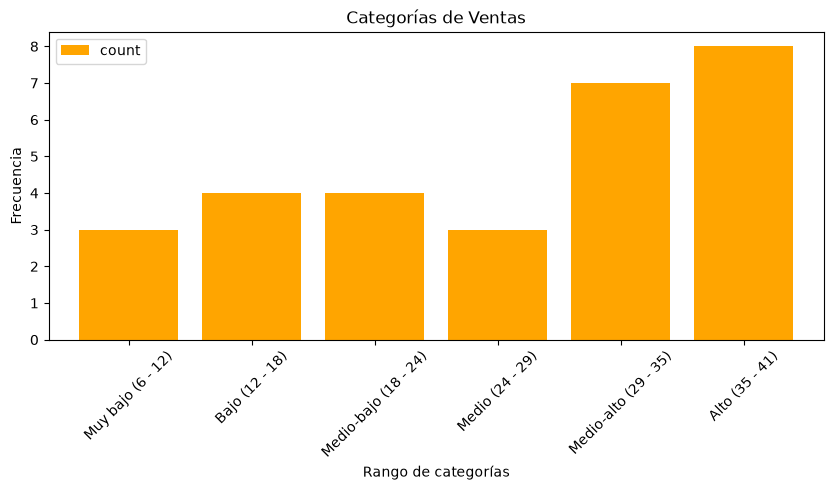

In [129]:
Filtro_index_ventas.plot(
    kind="bar",
    width=0.8,
    figsize=(10,4),
    color="orange",
    rot=45
)

plt.title("Categorías de Ventas")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")

plt.show()

In [147]:
# Datos válidos de Conversión
datos_conversion = pd.Series([
    3.1, 5.5, 2.8, 4.7, 1.0,
    3.7, 3.1, 3.2, 2.8, 2.1,
    3.3, 3.6, 4.3, 4.1, 3.4,
    4.9, 5.8, 4.0, 4.3, 6.2,
    5.8, 5.7, 4.7, 5.3, 4.1,
    4.3, 5.7, 4.8, 4.9, 11.7
])

In [148]:
print("Número de datos:", len(datos_conversion))
print("Mínimo:", datos_conversion.min())
print("Máximo:", datos_conversion.max())

Número de datos: 30
Mínimo: 1.0
Máximo: 11.7


In [149]:
# Número de datos
n_conversion = len(datos_conversion)

n_conversion

30

In [150]:
# Máximo y mínimo
Max_conversion = datos_conversion.max()
Min_conversion = datos_conversion.min()

Limites_conversion = [Min_conversion, Max_conversion]

Limites_conversion

[np.float64(1.0), np.float64(11.7)]

In [151]:
# Rango
R_conversion = Max_conversion - Min_conversion

R_conversion

np.float64(10.7)

In [152]:
# Regla de Sturges
ni_conversion = 1 + 3.32 * np.log10(n_conversion)

ni_conversion

np.float64(5.904042565669279)

In [153]:
# Ancho del intervalo
i_conversion = R_conversion / ni_conversion

i_conversion

np.float64(1.8123175571629797)

In [154]:
# Número de intervalos redondeado
ni_conversion_redondeado = round(ni_conversion)

ni_conversion_redondeado

6

In [155]:
intervalos_conversion = np.linspace(
    Min_conversion,
    Max_conversion,
    ni_conversion_redondeado + 1
)

intervalos_conversion

array([ 1.        ,  2.78333333,  4.56666667,  6.35      ,  8.13333333,
        9.91666667, 11.7       ])

In [158]:
niveles_conversion = [
    "Muy baja",
    "Baja",
    "Media-baja",
    "Media",
    "Media-alta",
    "Alta"
]

categorias_conversion = []

for x in range(ni_conversion_redondeado):

    etiqueta = (
        f"{niveles_conversion[x]} "
        f"({intervalos_conversion[x]:.2f}% - "
        f"{intervalos_conversion[x+1]:.2f}%)"
    )

    categorias_conversion.append(etiqueta)

categorias_conversion

['Muy baja (1.00% - 2.78%)',
 'Baja (2.78% - 4.57%)',
 'Media-baja (4.57% - 6.35%)',
 'Media (6.35% - 8.13%)',
 'Media-alta (8.13% - 9.92%)',
 'Alta (9.92% - 11.70%)']

In [159]:
conversion_categorizado = pd.cut(
    x=datos_conversion,
    bins=intervalos_conversion,
    labels=categorias_conversion,
    include_lowest=True
)

conversion_categorizado

0           Baja (2.78% - 4.57%)
1     Media-baja (4.57% - 6.35%)
2           Baja (2.78% - 4.57%)
3     Media-baja (4.57% - 6.35%)
4       Muy baja (1.00% - 2.78%)
5           Baja (2.78% - 4.57%)
6           Baja (2.78% - 4.57%)
7           Baja (2.78% - 4.57%)
8           Baja (2.78% - 4.57%)
9       Muy baja (1.00% - 2.78%)
10          Baja (2.78% - 4.57%)
11          Baja (2.78% - 4.57%)
12          Baja (2.78% - 4.57%)
13          Baja (2.78% - 4.57%)
14          Baja (2.78% - 4.57%)
15    Media-baja (4.57% - 6.35%)
16    Media-baja (4.57% - 6.35%)
17          Baja (2.78% - 4.57%)
18          Baja (2.78% - 4.57%)
19    Media-baja (4.57% - 6.35%)
20    Media-baja (4.57% - 6.35%)
21    Media-baja (4.57% - 6.35%)
22    Media-baja (4.57% - 6.35%)
23    Media-baja (4.57% - 6.35%)
24          Baja (2.78% - 4.57%)
25          Baja (2.78% - 4.57%)
26    Media-baja (4.57% - 6.35%)
27    Media-baja (4.57% - 6.35%)
28    Media-baja (4.57% - 6.35%)
29         Alta (9.92% - 11.70%)
dtype: cat

In [160]:
Tabla_freq_conversion = (
    conversion_categorizado
    .value_counts()
    .reset_index()
)

Tabla_freq_conversion.columns = [
    "Conversion",
    "count"
]

Tabla_freq_conversion

,Conversion,count
0,Baja (2.78% - 4.57%),15
1,Media-baja (4.57% - 6.35%),12
2,Muy baja (1.00% - 2.78%),2
3,Alta (9.92% - 11.70%),1
4,Media (6.35% - 8.13%),0
5,Media-alta (8.13% - 9.92%),0


In [161]:
Filtro_conversion = Tabla_freq_conversion[
    Tabla_freq_conversion["count"] > 0
]

Filtro_conversion

,Conversion,count
0,Baja (2.78% - 4.57%),15
1,Media-baja (4.57% - 6.35%),12
2,Muy baja (1.00% - 2.78%),2
3,Alta (9.92% - 11.70%),1


In [162]:
Filtro_index_conversion = (
    Filtro_conversion
    .set_index("Conversion")
)

In [163]:
Filtro_index_conversion = (
    Filtro_index_conversion
    .reindex(categorias_conversion)
    .dropna()
)

Filtro_index_conversion

,count
Conversion,
Muy baja (1.00% - 2.78%),2.0
Baja (2.78% - 4.57%),15.0
Media-baja (4.57% - 6.35%),12.0
Alta (9.92% - 11.70%),1.0


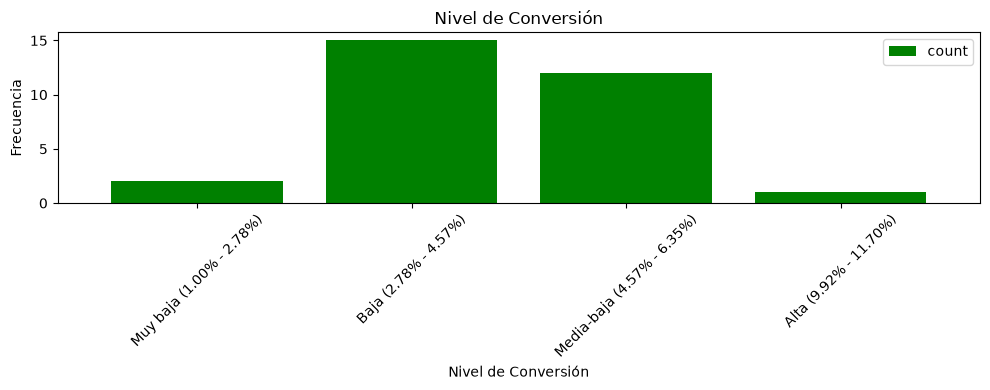

In [164]:
Filtro_index_conversion.plot(
    kind="bar",
    width=0.8,
    figsize=(10,4),
    color="green",
    rot=45
)

plt.title("Nivel de Conversión")
plt.xlabel("Nivel de Conversión")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()